In [1]:
import os
import glob
import os
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from tqdm import tqdm
import time
from scanpy.tools._utils import get_init_pos_from_paga 
from sklearn.metrics import mean_squared_error
import warnings
from scipy.interpolate import griddata
from scipy.stats import gaussian_kde

import torch
import rmm
import cupy
import cudf
import cupy as cp
from rmm.allocators.cupy import rmm_cupy_allocator
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

from cuml.manifold import UMAP
from cuml.decomposition import TruncatedSVD

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

from tqdm.notebook import tqdm

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/pseudotime.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 292 ms, sys: 2.98 s, total: 3.27 s
Wall time: 6.64 s


AnnData object with n_obs × n_vars = 6895 × 15906
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz', 'velocyto_cell_id', 'cell_id', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'leiden', 'cluster_phase', 'early_g1_score', 'G1_stage', 'global_ordering', 'global_ordering_bin', 'velocity_self_tra

coords.shape=(6895, 2) vel.shape=(6895, 2)


/tmp/ipykernel_3101788/177990769.py:28: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.scatterplot(


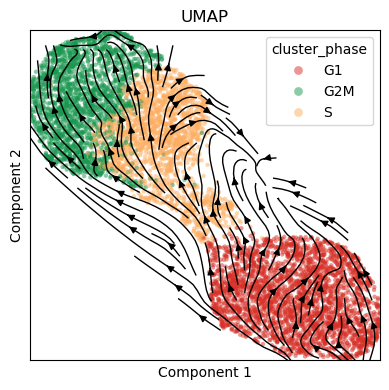

In [3]:
# Get coords and velocities
coords = adata.obsm["X_umap"]  # shape (n_cells, 2)
vel = -adata.obsm["velocity_umap"]  # shape (n_cells, 2)

print(f"{coords.shape=} {vel.shape=}")

x, y = coords[:, 0], coords[:, 1]
u, v = vel[:, 0], vel[:, 1]

# Create grid for interpolation
nbins = 25
xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()
X, Y = np.meshgrid(
    np.linspace(xmin, xmax, nbins),
    np.linspace(ymin, ymax, nbins)
)

# Interpolate velocity field onto grid (density-weighted)
kde = gaussian_kde(np.vstack([x, y]))
weights = kde(np.vstack([x, y]))

U = griddata((x, y), u*weights, (X, Y), method="linear", fill_value=0)
V = griddata((x, y), v*weights, (X, Y), method="linear", fill_value=0)

# Background scatter (cells)
plt.figure(figsize=(4, 4))
sns.scatterplot(
    x=x, y=y, s=10, ec='none',
    hue=adata.obs['cluster_phase'], 
    palette=adata.uns['cluster_phase_colors'],
    alpha=0.5,
)

# Streamplot
plt.streamplot(
    X, Y, U, V,
    color="k",
    density=1.5,
    linewidth=1,
    arrowsize=1
)

sns.move_legend(plt.gca(), loc='best', markerscale=2)

plt.title('UMAP')
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()


coords.shape=(6895, 50) vel.shape=(6895, 50)


/tmp/ipykernel_3101788/115467510.py:29: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.scatterplot(


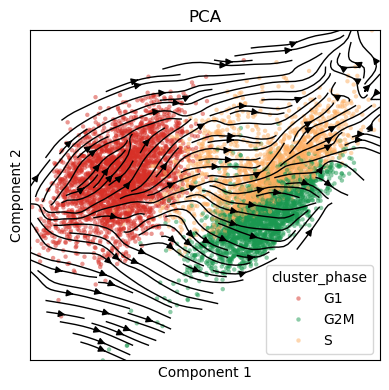

In [4]:
# Get coords and velocities
coords = adata.obsm["X_pca"]  # shape (n_cells, 2)
vel = -adata.obsm["velocity_pca"]  # shape (n_cells, 2)

print(f"{coords.shape=} {vel.shape=}")

x, y = coords[:, 0], coords[:, 1]
u, v = vel[:, 0], vel[:, 1]

# Create grid for interpolation
nbins = 25
xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()
X, Y = np.meshgrid(
    np.linspace(xmin, xmax, nbins),
    np.linspace(ymin, ymax, nbins)
)

# Interpolate velocity field onto grid (density-weighted)
kde = gaussian_kde(np.vstack([x, y]))
weights = kde(np.vstack([x, y]))

U = griddata((x, y), u*weights, (X, Y), method="linear", fill_value=0)
V = griddata((x, y), v*weights, (X, Y), method="linear", fill_value=0)

# Background scatter (cells)

plt.figure(figsize=(4, 4))
sns.scatterplot(
    x=x, y=y, s=10, ec='none',
    hue=adata.obs['cluster_phase'], 
    palette=adata.uns['cluster_phase_colors'],
    alpha=0.5,
)

# Streamplot
plt.streamplot(
    X, Y, U, V,
    color="k",
    density=1.5,
    linewidth=1,
    arrowsize=1
)

plt.title('PCA')
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()


# Add new sample labels

sample_labels
1     575
11    575
9     575
0     575
7     575
3     575
5     575
8     574
4     574
6     574
10    574
2     574


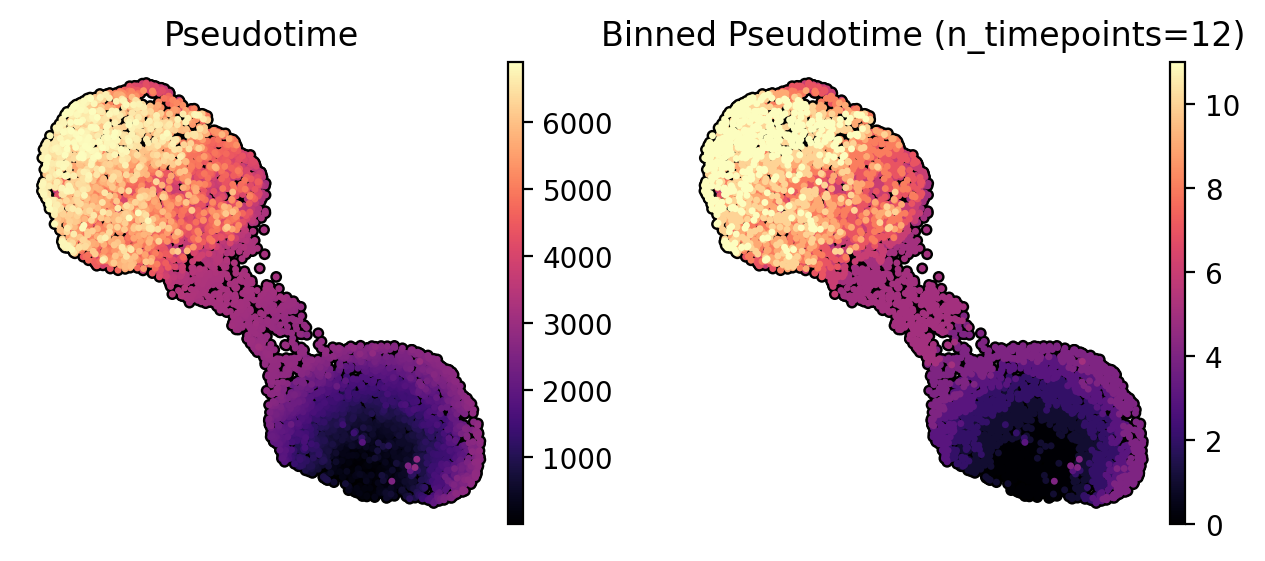

In [5]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

n_timepoints = 12  # number of bins

adata.obs['sample_labels'] = pd.cut(
    adata.obs['global_ordering'],
    bins=n_timepoints,
    labels=range(n_timepoints)
).astype(int)

print(adata.obs['sample_labels'].value_counts().to_string())
    
sc.pl.umap(
    adata,
    color=['global_ordering', 'sample_labels'],
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    cmap='magma',
    title=['Pseudotime', f'Binned Pseudotime ({n_timepoints=})'],
    frameon=False,
    wspace=0.25,
)

# If by phase 

In [6]:
# label_map = {
#     'G1' : 0,
#     'S' : 1,
#     'G2M' : 2,
# }
# adata.obs['sample_labels'] = adata.obs['cluster_phase'].map(label_map)
# adata.obs['sample_labels'].value_counts()

# Write out adata

In [7]:
# %%time

# outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/inputs/adata.h5ad"

# adata.write(outpath)
# adata

# Write out NPZ

In [8]:
components = [2, 5, 10, 15]
embeddings = ['pca', 'umap']

labels = adata.obs['sample_labels'].to_numpy()
n_labels = labels.size

fmt = lambda s: f"{s[0]}×{s[1]}"

for k in components:
    print(f"\n[k={k}] labels={n_labels}")

    # storage dict
    to_save = {
        'sample_labels' : labels,
    }

    for emb in embeddings:
        X  = adata.obsm[f"X_{emb}"]
        dV = adata.obsm[f"velocity_{emb}"]

        # choose usable components conservatively across both matrices
        use = min(k, X.shape[1], dV.shape[1])
        cap_dim = min(X.shape[1], dV.shape[1])
        cap = "" if use == k else f" (cap={cap_dim})"

        # create truncated copies
        Xk  = X[:, :use].copy()
        dVk = dV[:, :use].copy()

        # store 
        to_save[f'{emb}'] = Xk
        to_save[f'delta_{emb}'] = dVk

        print(f"\t{emb} | X={fmt(X.shape)} dV={fmt(dV.shape)} | comps={use}{cap}")

    # format ouput
    outpath = f"/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/inputs/input_{k}comp_{n_timepoints}time.npz"
    np.savez(outpath, **to_save)
    print(f"\tSaved to: {outpath}")

print('Done!')


[k=2] labels=6895
	pca | X=6895×50 dV=6895×50 | comps=2
	umap | X=6895×2 dV=6895×2 | comps=2
	Saved to: /nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/inputs/input_2comp_12time.npz

[k=5] labels=6895
	pca | X=6895×50 dV=6895×50 | comps=5
	umap | X=6895×2 dV=6895×2 | comps=2 (cap=2)
	Saved to: /nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/inputs/input_5comp_12time.npz

[k=10] labels=6895
	pca | X=6895×50 dV=6895×50 | comps=10
	umap | X=6895×2 dV=6895×2 | comps=2 (cap=2)
	Saved to: /nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/inputs/input_10comp_12time.npz

[k=15] labels=6895
	pca | X=6895×50 dV=6895×50 | comps=15
	umap | X=6895×2 dV=6895×2 | comps=2 (cap=2)
	Saved to: /nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/cell_cycle/inputs/input_15comp_12time.npz
Done!
